In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
df = pd.read_csv("Student Depression Dataset.csv")

In [3]:
selected_columns = [

    'Gender',

    'Age',

    'Academic Pressure',

    'CGPA',

    'Study Satisfaction',

    'Sleep Duration',

    'Dietary Habits',

    'Have you ever had suicidal thoughts ?',

    'Work/Study Hours',

    'Financial Stress',

    'Family History of Mental Illness',

    'Depression'
]

In [4]:
df = df[selected_columns]

In [5]:
df.columns = [

    'gender',

    'age',

    'academic_pressure',

    'cgpa',

    'study_satisfaction',

    'sleep_duration',

    'dietary_habits',

    'suicidal_thoughts',

    'work_study_hours',

    'financial_stress',

    'family_history',

    'depression'
]

In [18]:
y = df['depression']

X = df.drop('depression', axis=1)

In [28]:
categorical_columns = X.select_dtypes(include=['object']).columns

numerical_columns = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:\n")

print(categorical_columns)

print("\nNumerical Columns:\n")

print(numerical_columns)

Categorical Columns:

Index([], dtype='object')

Numerical Columns:

Index(['gender', 'age', 'academic_pressure', 'cgpa', 'study_satisfaction',
       'sleep_duration', 'dietary_habits', 'suicidal_thoughts',
       'work_study_hours', 'financial_stress', 'family_history'],
      dtype='object')


In [29]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

In [30]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            'cat',

            OneHotEncoder(drop='first'),

            categorical_columns
        ),

        (

            'num',

            StandardScaler(),

            numerical_columns
        )
    ]
)

In [31]:
X_processed = preprocessor.fit_transform(X)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(

    X_processed,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [43]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import AdaBoostClassifier

from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

from lightgbm import LGBMClassifier

In [44]:
from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

In [45]:
models = {

    "Logistic Regression": LogisticRegression(),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "AdaBoost": AdaBoostClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),

    "CatBoost": CatBoostClassifier(verbose=0),

    "LightGBM": LGBMClassifier()
}

In [46]:
model_names = []

accuracies = []

AttributeError: 'numpy.ndarray' object has no attribute 'toarray'

In [50]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import AdaBoostClassifier

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

from lightgbm import LGBMClassifier

import pandas as pd

import joblib



models = {

    "Logistic Regression": LogisticRegression(),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(probability=True),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "AdaBoost": AdaBoostClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(eval_metric='logloss'),

    "CatBoost": CatBoostClassifier(verbose=0),

    "LightGBM": LGBMClassifier()
}



results = []

best_accuracy = 0

best_model = None

best_model_name = ""



for name, model in models.items():

    print("\n" + "="*50)

    print(f"TRAINING : {name}")

    print("="*50)



    try:

        model.fit(X_train, y_train)



        y_pred = model.predict(X_test)



        accuracy = accuracy_score(y_test, y_pred)



        print(f"\nAccuracy : {accuracy:.4f}")



        print("\nClassification Report:\n")

        print(classification_report(y_test, y_pred))



        results.append([name, accuracy])



        if accuracy > best_accuracy:

            best_accuracy = accuracy

            best_model = model

            best_model_name = name



    except Exception as e:

        print(f"\nError in {name}")

        print(e)



results_df = pd.DataFrame(

    results,

    columns=['Model', 'Accuracy']
)



results_df = results_df.sort_values(

    by='Accuracy',

    ascending=False
)



print("\n")

print("="*60)

print("FINAL TOURNAMENT LEADERBOARD")

print("="*60)



print(results_df)



print("\n")

print("="*60)

print(f"BEST MODEL : {best_model_name}")

print(f"BEST ACCURACY : {best_accuracy:.4f}")

print("="*60)



joblib.dump(best_model, 'best_model.pkl')

joblib.dump(preprocessor, 'preprocessor.pkl')


TRAINING : Logistic Regression

Error in Logistic Regression
Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

TRAINING : KNN

Error in KNN
Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. 

C:\Users\workk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


['preprocessor.pkl']

In [51]:
results_df.reset_index(drop=True, inplace=True)

results_df.index = results_df.index + 1

results_df

,Model,Accuracy
1,CatBoost,0.845547
2,LightGBM,0.841247
3,XGBoost,0.835513
4,Random Forest,0.833901
5,Decision Tree,0.760616


In [55]:
best_predictions = best_model.predict(X_test)

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    best_predictions
)

cm

array([[1837,  476],
       [ 386, 2882]])

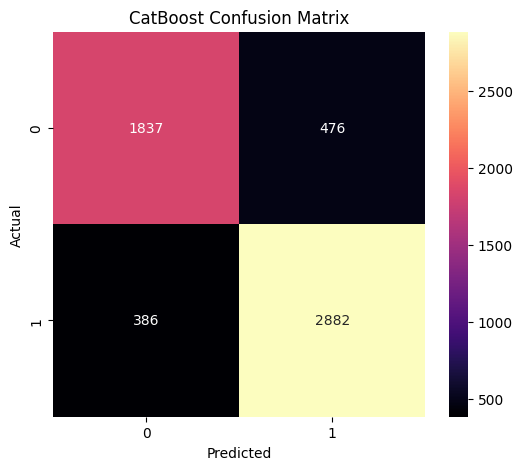

In [57]:
plt.figure(figsize=(6,5))

plt.gca().set_facecolor('#0d1117')

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='magma'
)

plt.title(f"{best_model_name} Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [58]:
feature_names = preprocessor.get_feature_names_out()

In [59]:
importance = best_model.feature_importances_

In [60]:
importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': importance
})

In [61]:
importance_df = importance_df.sort_values(

    by='Importance',

    ascending=False
)

In [63]:
top_features = importance_df.head(15)

C:\Users\workk\AppData\Local\Temp\ipykernel_18128\3696900200.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


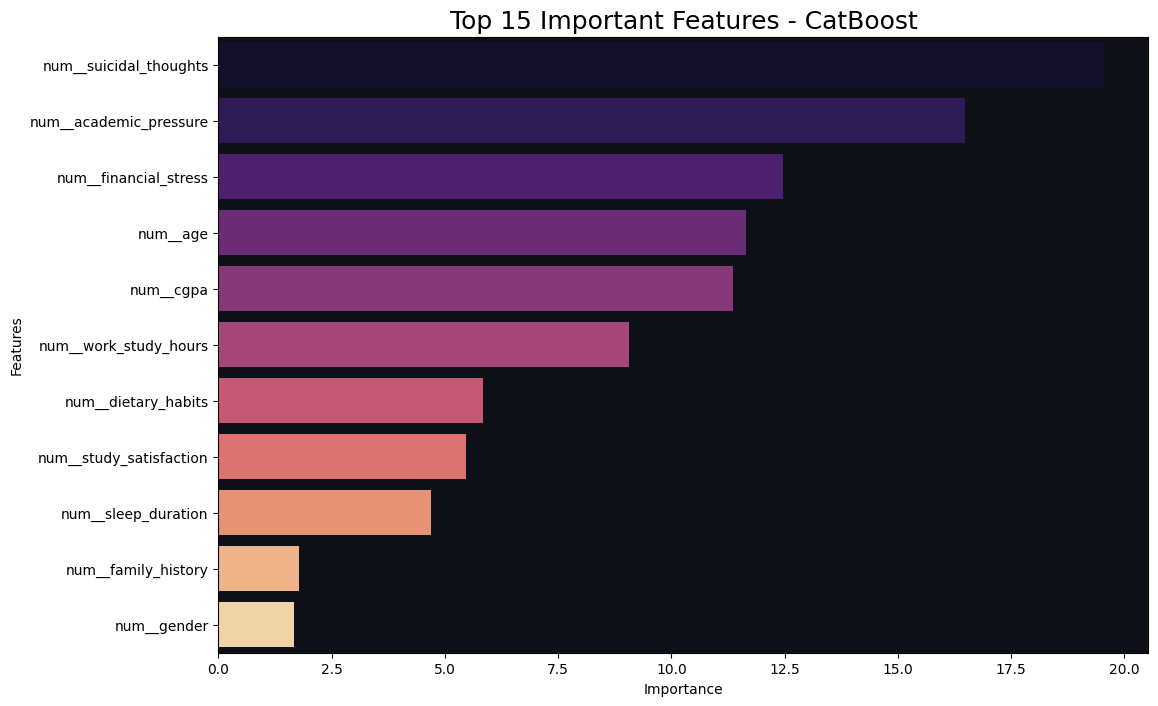

In [64]:
plt.figure(figsize=(12,8))

plt.gca().set_facecolor('#0d1117')

sns.barplot(

    x='Importance',

    y='Feature',

    data=top_features,

    palette='magma'
)

plt.title(

    f"Top 15 Important Features - {best_model_name}",

    fontsize=18
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

In [65]:
import joblib

joblib.dump(

    best_model,

    'best_model.pkl'
)

['best_model.pkl']

In [66]:
joblib.dump(

    preprocessor,

    'preprocessor.pkl'
)

['preprocessor.pkl']